# Librerias

In [1]:
import pandas as pd
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt

# Carga de la bbdd y reducción

## 1. Cargar csv

In [2]:
#cargar datos
df = pd.read_parquet("../data/df_limpiado_260420.parquet")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,contactado_campania_previa
id,,,,,,,,,,,,,,,,,,
1,59.0,administration,married,secondary,no,2343,yes,no,unknown,5,may,1042.0,1,NaN,0,sin_campania_previa,yes,0
2,56.0,administration,married,secondary,no,45,no,no,unknown,5,may,1467.0,1,NaN,0,sin_campania_previa,yes,0
3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389.0,1,NaN,0,sin_campania_previa,yes,0
4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579.0,1,NaN,0,sin_campania_previa,yes,0
5,54.0,administration,married,tertiary,no,184,no,no,unknown,5,may,673.0,2,NaN,0,sin_campania_previa,yes,0


In [3]:
#Nos quedamos con las variables que usaremos para segmentar
cols = ["age", "job", "marital", "education", "housing", "loan", "deposit"]

df_perfil = df[cols].copy()
df_perfil.head()

,age,job,marital,education,housing,loan,deposit
id,,,,,,,
1,59.0,administration,married,secondary,yes,no,yes
2,56.0,administration,married,secondary,no,no,yes
3,41.0,technician,married,secondary,yes,no,yes
4,55.0,services,married,secondary,yes,no,yes
5,54.0,administration,married,tertiary,no,no,yes


## 2. Categorizar edad

In [4]:
df_perfil["age_group"] = pd.cut(df_perfil["age"], bins=[0, 25, 35, 45, 55, 65, 120], labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"])

#Eliminamos la columna numérica original
df_perfil = df_perfil.drop(columns=["age"])

## 3. Convertir todas a categóricas

In [5]:
for col in df_perfil.columns:
    df_perfil[col] = df_perfil[col].astype(str)

In [6]:
df_perfil = df_perfil.reset_index(drop=True)
df_perfil.info()

<class 'pandas.DataFrame'>
RangeIndex: 10642 entries, 0 to 10641
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   job        10642 non-null  str  
 1   marital    10642 non-null  str  
 2   education  10642 non-null  str  
 3   housing    10642 non-null  str  
 4   loan       10642 non-null  str  
 5   deposit    10642 non-null  str  
 6   age_group  10642 non-null  str  
dtypes: str(7)
memory usage: 970.7 KB


# Perfil del cliente

## 1. Preparar datos para K‑Modes

In [7]:
cols_modelo = ["age_group", "job", "marital", "education"]

df_perfil_m = df_perfil[cols_modelo].copy()
df_perfil_m.head()

,age_group,job,marital,education
0,56-65,administration,married,secondary
1,56-65,administration,married,secondary
2,36-45,technician,married,secondary
3,46-55,services,married,secondary
4,46-55,administration,married,tertiary


In [8]:
data_model = df_perfil_m.copy()
X = data_model.to_numpy()

## 2. Método del codo para elegir k

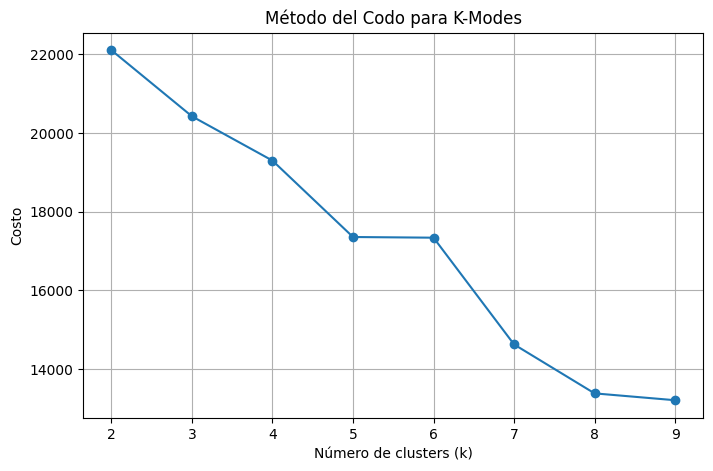

In [9]:
costs = []
ks = range(2, 10)

for k in ks:
    km = KModes(n_clusters=k, init='Cao', n_init=5, verbose=0)
    clusters = km.fit_predict(X)
    costs.append(km.cost_)

# Graficar la curva del codo, el “codo” es donde la curva deja de bajar bruscamente, ese será k óptimo
plt.figure(figsize=(8,5))
plt.plot(ks, costs, marker='o')
plt.title("Método del Codo para K-Modes")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Costo")
plt.grid(True)
plt.show()

## 3. Entrenar K‑Modes

In [10]:
k_opt = 5

km = KModes(n_clusters=k_opt, init='Cao', n_init=5, verbose=0)
clusters = km.fit_predict(X)

In [11]:
df_perfil["cluster"] = clusters
df_perfil["cluster"].value_counts().sort_index()

cluster
0    5375
1    1710
2    1173
3     976
4    1408
Name: count, dtype: int64

## 3. Ver los centroides de cada cluster

In [12]:
centroides = km.cluster_centroids_
centroides

array([['26-35', 'management', 'married', 'secondary'],
       ['36-45', 'technician', 'single', 'tertiary'],
       ['46-55', 'technician', 'married', 'tertiary'],
       ['46-55', 'administration', 'single', 'secondary'],
       ['36-45', 'blue-collar', 'married', 'primary']], dtype='<U14')

## 4. Perfil de productos por cluster

In [13]:
perfil_clusters = pd.DataFrame(km.cluster_centroids_, columns=cols_modelo)

perfil_clusters.index = [f"Cluster {i}" for i in range(perfil_clusters.shape[0])]

perfil_clusters

,age_group,job,marital,education
Cluster 0,26-35,management,married,secondary
Cluster 1,36-45,technician,single,tertiary
Cluster 2,46-55,technician,married,tertiary
Cluster 3,46-55,administration,single,secondary
Cluster 4,36-45,blue-collar,married,primary


## 5. Perfil demográfico por cluster

In [14]:
#Distribución de age_group:
cluster_age = pd.crosstab(df_perfil["cluster"], df_perfil["age_group"], normalize="index")
cluster_age

age_group,26-35,36-45,46-55,56-65,65+,<=25
cluster,,,,,,
0,0.530233,0.225488,0.087814,0.119070,0.030326,0.007070
1,0.263743,0.552632,0.042105,0.031579,0.008187,0.101754
2,0.066496,0.000000,0.803922,0.081841,0.042626,0.005115
3,0.211066,0.150615,0.377049,0.040984,0.003074,0.217213
4,0.111506,0.486506,0.127841,0.152699,0.115767,0.005682


In [15]:
#Distribución de job:
cluster_job = pd.crosstab(df_perfil["cluster"], df_perfil["job"], normalize="index")
cluster_job

job,administration,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
cluster,,,,,,,,,,,,
0,0.091349,0.129116,0.026977,0.016186,0.328000,0.062512,0.031442,0.118884,0.018419,0.136744,0.034791,0.005581
1,0.065497,0.052047,0.045614,0.016959,0.184795,0.023977,0.083626,0.053801,0.082456,0.333333,0.051462,0.006433
2,0.023870,0.023870,0.042626,0.055413,0.288150,0.104859,0.044331,0.038363,0.000853,0.346974,0.016198,0.014493
3,0.639344,0.076844,0.012295,0.012295,0.008197,0.014344,0.012295,0.065574,0.113730,0.016393,0.026639,0.002049
4,0.017045,0.670455,0.016335,0.045455,0.015625,0.171165,0.008523,0.029119,0.001420,0.006392,0.012784,0.005682


In [16]:
#Distribución de marital:
cluster_marital = pd.crosstab(df_perfil["cluster"], df_perfil["marital"], normalize="index")
cluster_marital

marital,divorced,married,single
cluster,,,
0,0.077023,0.671442,0.251535
1,0.134503,0.110526,0.754971
2,0.161978,0.838022,0.000000
3,0.210041,0.127049,0.662910
4,0.137784,0.801847,0.060369


In [17]:
#Distribución de education:
cluster_edu = pd.crosstab(df_perfil["cluster"], df_perfil["education"], normalize="index")
cluster_edu

education,primary,secondary,tertiary,unknown
cluster,,,,
0,0.019907,0.649674,0.291349,0.039070
1,0.032164,0.184795,0.721053,0.061988
2,0.132140,0.184996,0.614663,0.068201
3,0.023566,0.950820,0.006148,0.019467
4,0.766335,0.190341,0.002131,0.041193


In [18]:
#Relación deposit:
df_perfil.groupby("cluster")["deposit"].value_counts(normalize=True)

cluster  deposit
0        no         0.511628
         yes        0.488372
1        yes        0.583041
         no         0.416959
2        no         0.520034
         yes        0.479966
3        yes        0.553279
         no         0.446721
4        no         0.599432
         yes        0.400568
Name: proportion, dtype: float64

In [19]:
cluster_deposit = pd.crosstab(df_perfil["cluster"], df_perfil["deposit"], normalize="index")
cluster_deposit

deposit,no,yes
cluster,,
0,0.511628,0.488372
1,0.416959,0.583041
2,0.520034,0.479966
3,0.446721,0.553279
4,0.599432,0.400568


In [20]:
#Relación loan:
df_perfil.groupby("cluster")["loan"].value_counts(normalize=True)

cluster  loan
0        no      0.869395
         yes     0.130605
1        no      0.912865
         yes     0.087135
2        no      0.865303
         yes     0.134697
3        no      0.832992
         yes     0.167008
4        no      0.857955
         yes     0.142045
Name: proportion, dtype: float64

In [21]:
cluster_loan = pd.crosstab(df_perfil["cluster"], df_perfil["loan"], normalize="index")
cluster_loan

loan,no,yes
cluster,,
0,0.869395,0.130605
1,0.912865,0.087135
2,0.865303,0.134697
3,0.832992,0.167008
4,0.857955,0.142045


In [22]:
#Relación housing:
df_perfil.groupby("cluster")["housing"].value_counts(normalize=True)

cluster  housing
0        no         0.516093
         yes        0.483907
1        no         0.585380
         yes        0.414620
2        no         0.638534
         yes        0.361466
3        no         0.533811
         yes        0.466189
4        yes        0.563210
         no         0.436790
Name: proportion, dtype: float64

In [23]:
cluster_housing = pd.crosstab(df_perfil["cluster"], df_perfil["housing"], normalize="index")
cluster_housing

housing,no,yes
cluster,,
0,0.516093,0.483907
1,0.585380,0.414620
2,0.638534,0.361466
3,0.533811,0.466189
4,0.436790,0.563210


## 6. Conclusiones